<a href="https://colab.research.google.com/github/mahekpatel236/Data-Analytics-Project/blob/main/Data_Analytics_Project_Movies_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/movies.csv",encoding = 'unicode_escape')
df

,Rank,Title,Studio,Gross,Year
0,1,Avengers: Endgame,Buena Vista,"$2,796.30",2019
1,2,Avatar,Fox,"$2,789.70",2009
2,3,Titanic,Paramount,"$2,187.50",1997
3,4,Star Wars: The Force Awakens,Buena Vista,"$2,068.20",2015
4,5,Avengers: Infinity War,Buena Vista,"$2,048.40",2018
...,...,...,...,...,...
777,778,Yogi Bear,Warner Brothers,$201.60,2010
778,779,Garfield: The Movie,Fox,$200.80,2004
779,780,Cats & Dogs,Warner Brothers,$200.70,2001
780,781,The Hunt for Red October,Paramount,$200.50,1990


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.shape

(782, 5)

In [ ]:
df.head()

,Rank,Title,Studio,Gross,Year
0,1,Avengers: Endgame,Buena Vista,"$2,796.30",2019
1,2,Avatar,Fox,"$2,789.70",2009
2,3,Titanic,Paramount,"$2,187.50",1997
3,4,Star Wars: The Force Awakens,Buena Vista,"$2,068.20",2015
4,5,Avengers: Infinity War,Buena Vista,"$2,048.40",2018


In [ ]:
df.tail()

,Rank,Title,Studio,Gross,Year
777,778,Yogi Bear,Warner Brothers,$201.60,2010
778,779,Garfield: The Movie,Fox,$200.80,2004
779,780,Cats & Dogs,Warner Brothers,$200.70,2001
780,781,The Hunt for Red October,Paramount,$200.50,1990
781,782,Valkyrie,MGM,$200.30,2008


In [ ]:
df.sample(5)

,Rank,Title,Studio,Gross,Year
303,304,Monster Hunt,FR,$385.30,2016
486,487,Doctor Dolittle,Fox,$294.50,1998
232,233,The Matrix,Warner Brothers,$463.50,1999
753,754,Sleepy Hollow,Paramount,$206.10,1999
365,366,The Angry Birds Movie,Sony,$352.30,2016


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Rank    782 non-null    int64 
 1   Title   782 non-null    object
 2   Studio  782 non-null    object
 3   Gross   782 non-null    object
 4   Year    782 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 30.7+ KB


In [ ]:
pd.isnull(df).sum()

,0
Rank,0
Title,0
Studio,0
Gross,0
Year,0


In [ ]:
df.describe()

,Rank,Year
count,782.000000,782.000000
mean,391.500000,2006.620205
std,225.888247,10.026227
min,1.000000,1939.000000
25%,196.250000,2001.000000
50%,391.500000,2009.000000
75%,586.750000,2014.000000
max,782.000000,2019.000000


From this information Total count of rows is 782.
Mean of rank is 391 and year is 2006.
Minimum rank is 1 and Minimum year is 1939.
Maximum rank is 782 and Maximum year is 2019.

In [ ]:
df['Gross'] = df['Gross'].astype(str)
df['Gross'] = df['Gross'].str.replace('$', '', regex=False)
df['Gross'] = df['Gross'].str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

In [ ]:
df

,Rank,Title,Studio,Gross,Year
0,1,Avengers: Endgame,Buena Vista,2796.3,2019
1,2,Avatar,Fox,2789.7,2009
2,3,Titanic,Paramount,2187.5,1997
3,4,Star Wars: The Force Awakens,Buena Vista,2068.2,2015
4,5,Avengers: Infinity War,Buena Vista,2048.4,2018
...,...,...,...,...,...
777,778,Yogi Bear,Warner Brothers,201.6,2010
778,779,Garfield: The Movie,Fox,200.8,2004
779,780,Cats & Dogs,Warner Brothers,200.7,2001
780,781,The Hunt for Red October,Paramount,200.5,1990


/tmp/ipython-input-402833961.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gross', y='Title', data=top10_gross, palette='magma')


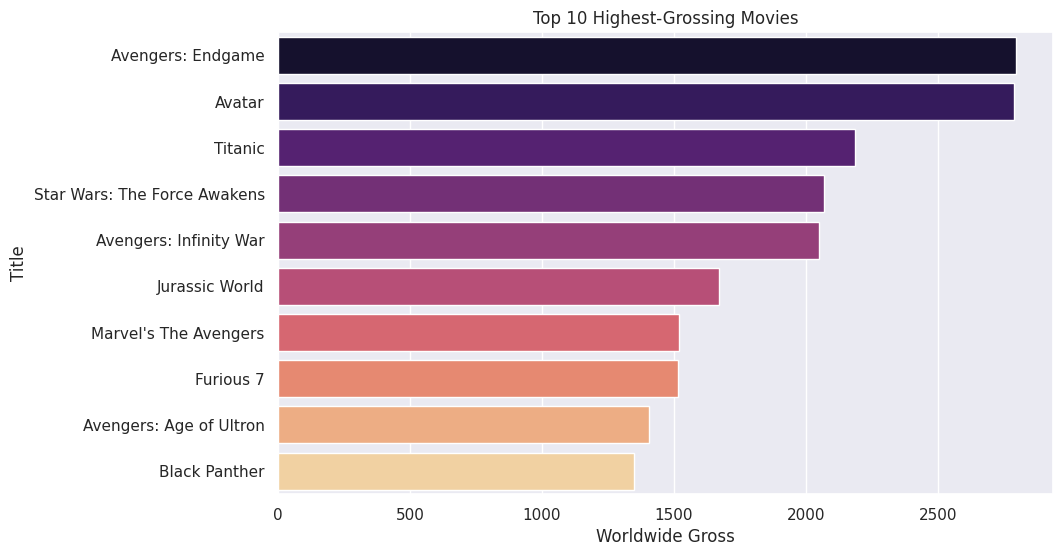

In [ ]:
top10_gross = df.nlargest(10, 'Gross')[['Title', 'Gross']]

plt.figure(figsize=(10, 6))
sns.barplot(x='Gross', y='Title', data=top10_gross, palette='magma')
plt.title('Top 10 Highest-Grossing Movies')
plt.xlabel('Worldwide Gross')
plt.show()

Higest grossing movies is Avengers:Endgame and Avtar

/tmp/ipython-input-1636066914.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Year',y = 'Gross',data = movies,palette = 'coolwarm')


<Axes: xlabel='Year', ylabel='Gross'>

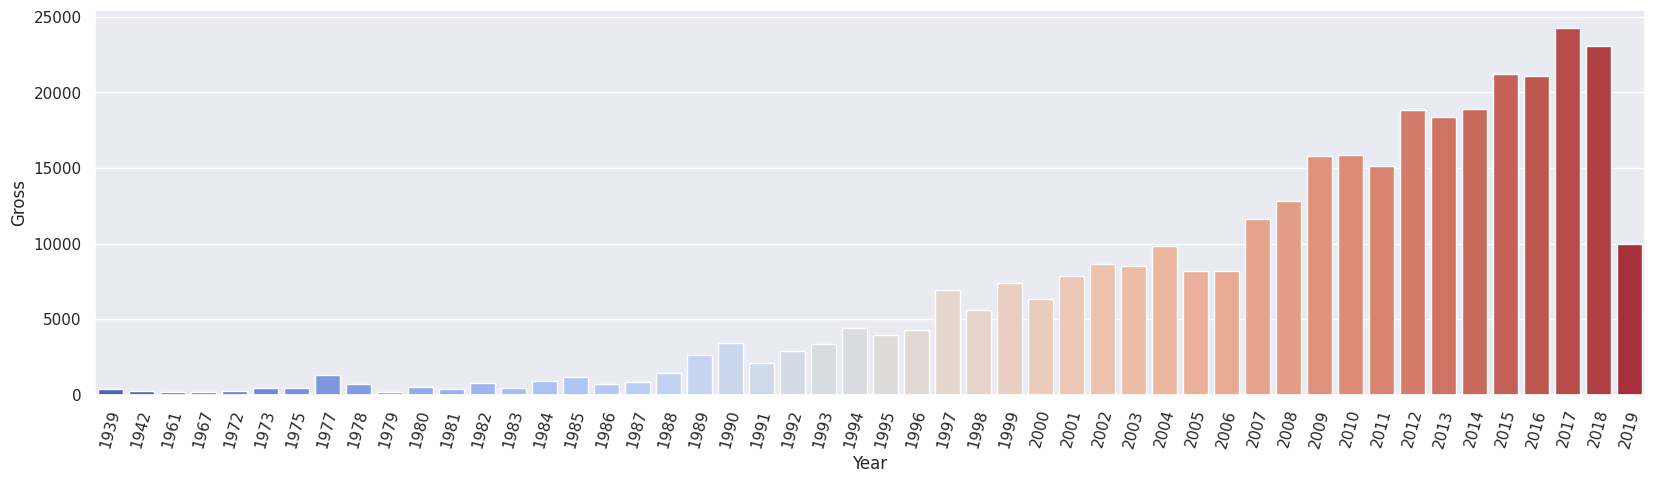

In [ ]:
sns.set(rc={'figure.figsize':(20,5)})
movies = df.groupby(['Year'],as_index=False)['Gross'].sum().sort_values(by = 'Gross',ascending=False)
plt.xticks(rotation = 75)
sns.barplot(x = 'Year',y = 'Gross',data = movies,palette = 'coolwarm')

From above graph we can see that year wise gross highest grossing year is  2017, 2018 and 2015

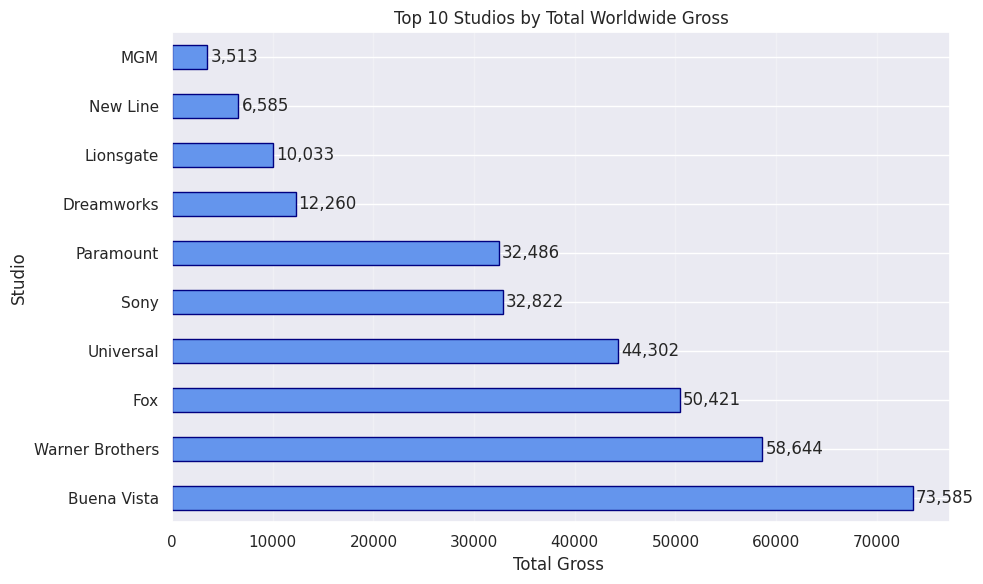

In [ ]:
studio_total = df.groupby('Studio')['Gross'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
studio_total.plot(kind='barh', color='cornflowerblue', edgecolor='navy')

for i, v in enumerate(studio_total):
    plt.text(v + 300, i, f"{v:,.0f}", va='center')

plt.title("Top 10 Studios by Total Worldwide Gross")
plt.xlabel("Total Gross ")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

From above graph we can see that highest grossing studio is Buena Vista, Warner Brothers and Fox

<Figure size 2500x800 with 0 Axes>

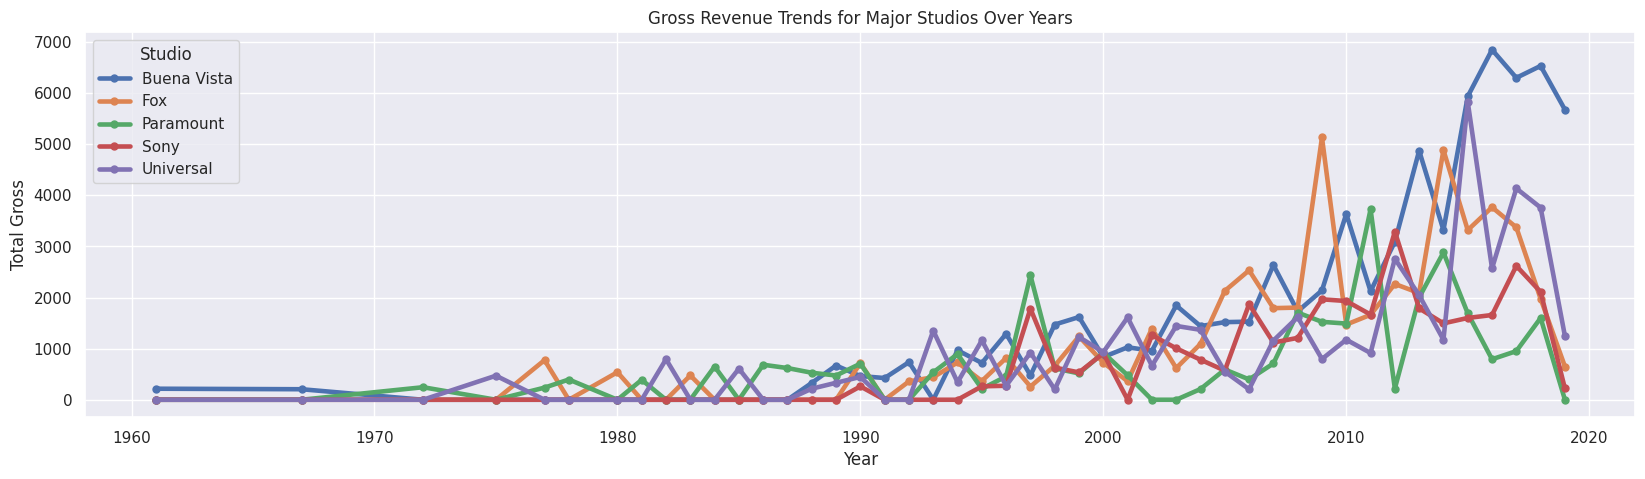

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

major = ['Buena Vista', 'Universal', 'Fox', 'Sony', 'Paramount']
df_major = df[df['Studio'].isin(major)]

year_studio = df_major.groupby(['Year', 'Studio'])['Gross'].sum().unstack().fillna(0)

plt.figure(figsize=(25, 8))
year_studio.plot(linewidth=3.3, marker='o', markersize=5)
plt.title('Gross Revenue Trends for Major Studios Over Years')
plt.xlabel('Year')
plt.ylabel('Total Gross')
plt.legend(title='Studio')
plt.grid(True)
plt.show()

From above graph we can see that studio's gross increse between 2010 to 2020

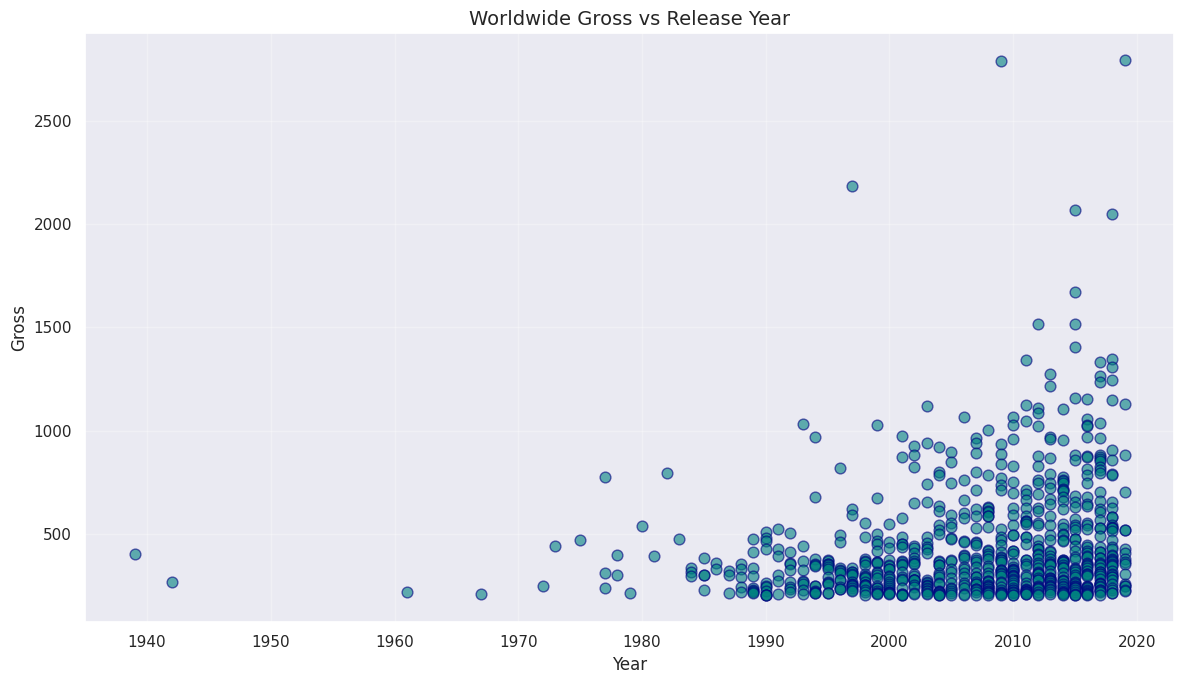

In [ ]:
plt.figure(figsize=(12, 7))
plt.scatter(df['Year'], df['Gross'], alpha=0.6, color='teal', s=60, edgecolor='navy')

plt.title("Worldwide Gross vs Release Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Gross")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

From above graph we can see that in movies world wide gross increse between years 2010 to 2020

Conclusion:


Buena Vista, Warner Brothers and Fox is top stodios world wide highest grossing between year 2010 to *2020*